In [236]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

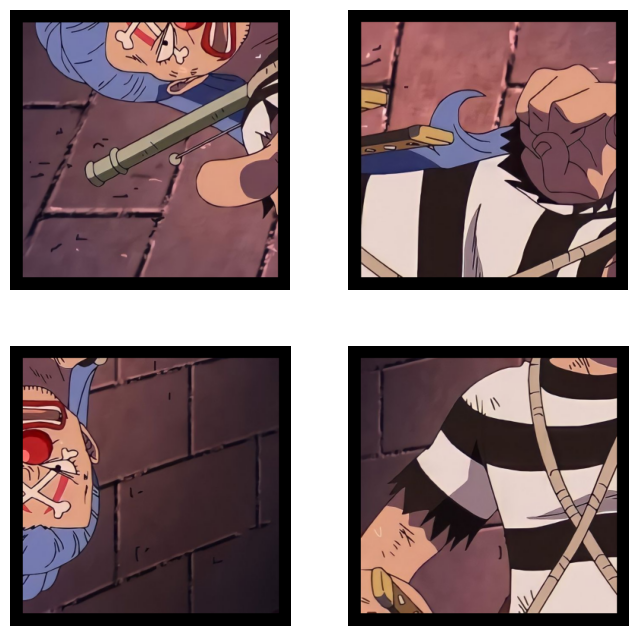

In [237]:
import cv2 as cv
import matplotlib.pyplot as plt

img1 = cv.imread("assets/buggy1.png")
img2 = cv.imread("assets/buggy2.png")
img3 = cv.imread("assets/buggy3.png")
img4 = cv.imread("assets/buggy4.png")

# Konversi BGR ke RGB
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)
img3 = cv.cvtColor(img3, cv.COLOR_BGR2RGB)
img4 = cv.cvtColor(img4, cv.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(img1)
plt.axis('OFF')

plt.subplot(2,2,2)
plt.imshow(img2)
plt.axis('OFF')

plt.subplot(2,2,3)
plt.imshow(img3)
plt.axis('OFF')

plt.subplot(2,2,4)
plt.imshow(img4)
plt.axis('OFF')

plt.show()

(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

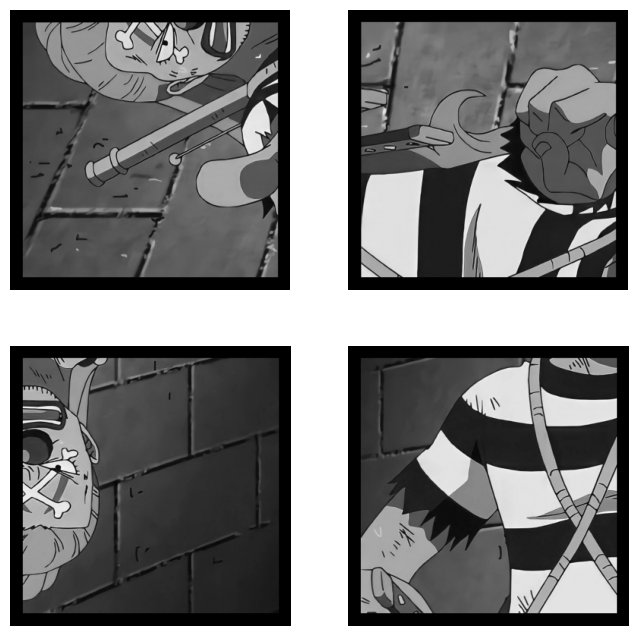

In [238]:
gray1 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
gray3 = cv.cvtColor(img3, cv.COLOR_BGR2GRAY)
gray4 = cv.cvtColor(img4, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(gray1, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(gray2, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(gray3, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(gray4, cmap='gray')
plt.axis('off')

In [239]:
def rotasi90(img):
    h, w = img.shape
    hasil = np.zeros((w, h), dtype=img.dtype)

    for i in range(h):
        for j in range(w):
            hasil[j, h - 1 - i] = img[i, j]

    return hasil

def rotasi270(img):
    h, w = img.shape
    hasil = np.zeros((w, h), dtype=img.dtype)

    for i in range(h):
        for j in range(w):
            hasil[w - 1 - j, i] = img[i, j]

    return hasil

In [240]:
def fliping(img, mode='X'):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=img.dtype)

    for i in range(h):
        for j in range(w):
            if mode == 'X':    
                hasil[i, j] = img[h - 1 - i, j]
            elif mode == 'Y': 
                hasil[i, j] = img[i, w - 1 - j]

    return hasil

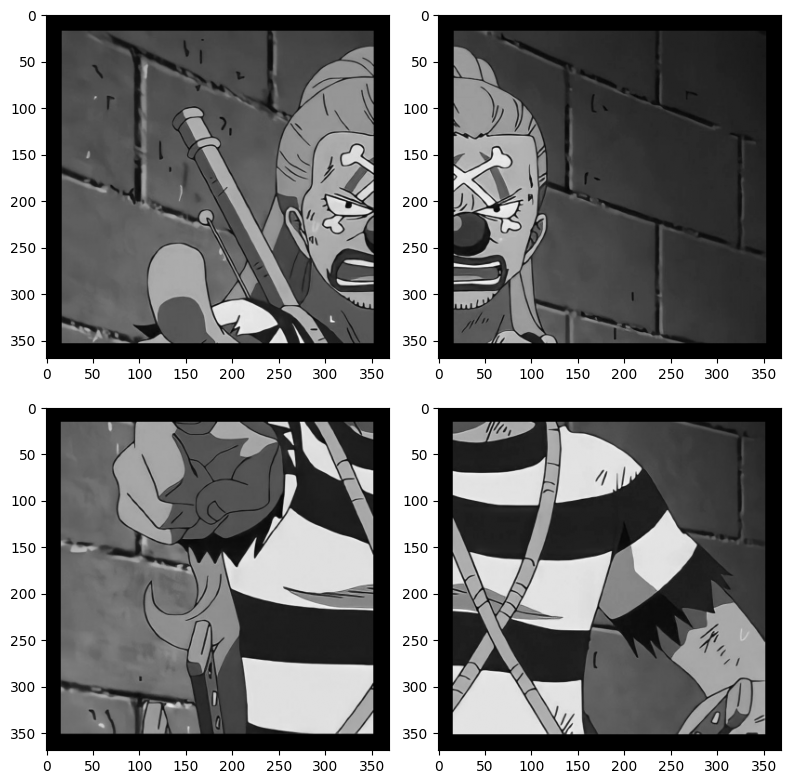

In [241]:
rot1 = rotasi90(gray1)
rot2 = rotasi270(gray2)

flip3 = fliping(gray3, 'X')
flip4 = fliping(gray4, 'Y')

img1_fix = rot1
img2_fix = flip3
img3_fix = rot2
img4_fix = flip4

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(img1_fix, cmap='gray')

plt.subplot(2,2,2)
plt.imshow(img2_fix, cmap='gray')

plt.subplot(2,2,3)
plt.imshow(img3_fix, cmap='gray')

plt.subplot(2,2,4)
plt.imshow(img4_fix, cmap='gray')

plt.tight_layout()
plt.show()

In [242]:
crop1 = img1_fix[17:-17, 17:-17]
crop2 = img2_fix[17:-17, 17:-17]
crop3 = img3_fix[17:-17, 17:-17]
crop4 = img4_fix[17:-17, 17:-17]

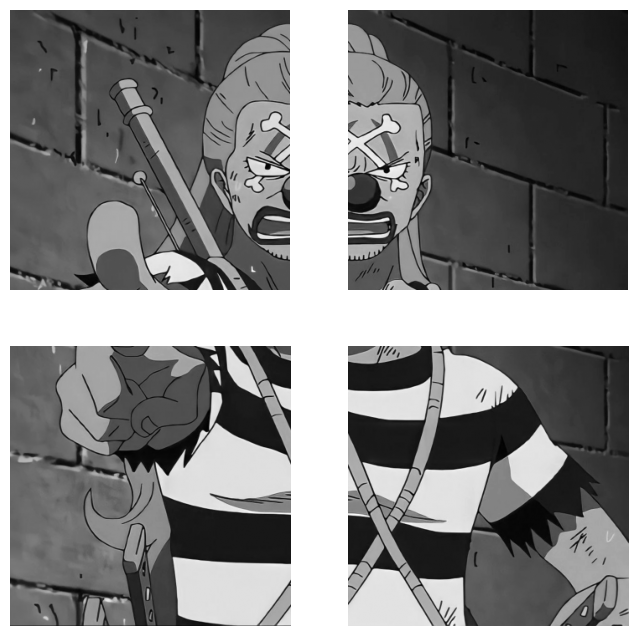

In [243]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(crop1, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(crop2, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(crop3, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(crop4, cmap='gray')
plt.axis('off')

plt.show()

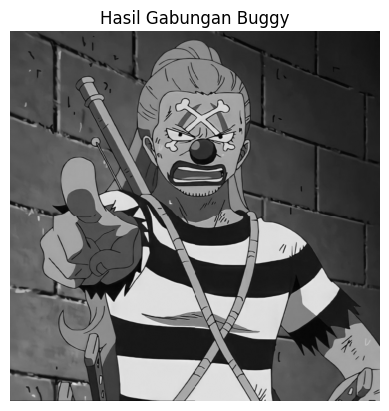

In [244]:
h, w = crop1.shape

kanvass = np.zeros((h*2, w*2))

kanvass[0:h, 0:w] = crop1
kanvass[0:h, w:2*w] = crop2
kanvass[h:2*h, 0:w] = crop3
kanvass[h:2*h, w:2*w] = crop4


kanvasBagi2 = (kanvass.astype(np.float32) / 2)
plt.imshow(kanvasBagi2, cmap='gray')
plt.title("Hasil Gabungan Buggy")
plt.axis('off')
plt.show()

In [245]:
kanvas = kanvasBagi2.astype(np.float32)

kanvas_norm = (kanvas - kanvas.min()) / (kanvas.max() - kanvas.min()) * 255
kanvas_norm = kanvas_norm.astype(np.uint8) 

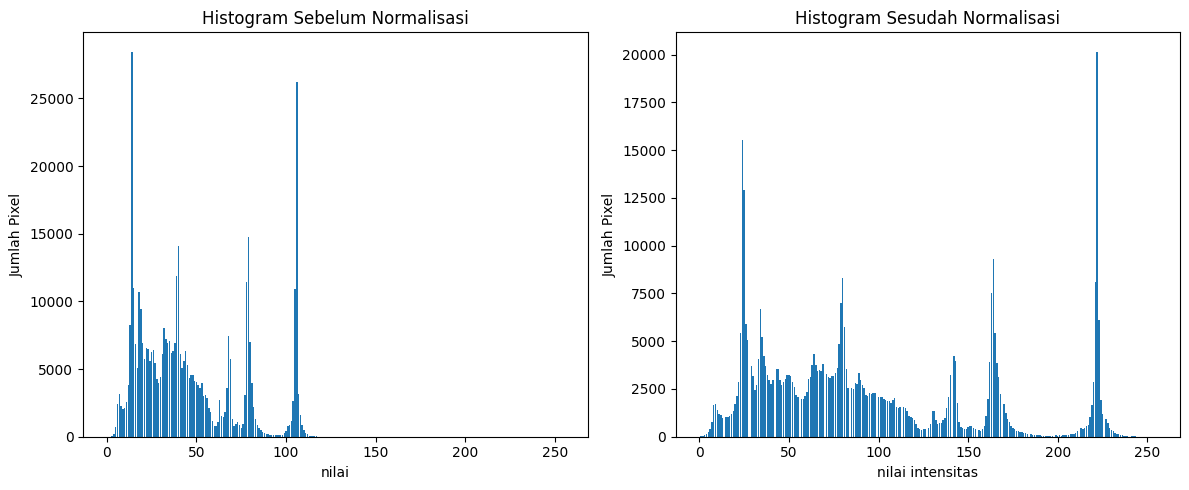

In [246]:
hist_before = np.zeros(256)
hist_after = np.zeros(256)

h, w = kanvas.shape

for i in range(h):
    for j in range(w):
        hist_before[int(kanvas[i, j])] += 1
        hist_after[int(kanvas_norm[i, j])] += 1

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(range(256), hist_before)
plt.title("Histogram Sebelum Normalisasi")
plt.xlabel("nilai")
plt.ylabel("Jumlah Pixel")

plt.subplot(1,2,2)
plt.bar(range(256), hist_after)
plt.title("Histogram Sesudah Normalisasi")
plt.xlabel("nilai intensitas")
plt.ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()

In [247]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

In [248]:
pad = 2
img = kanvas_norm.astype(np.float32)

padded = np.pad(img, pad_width=pad, mode='constant', constant_values=0)

h, w = img.shape
output = np.zeros((h, w), dtype=np.float32)

for i in range(h):
    for j in range(w):
        region = padded[i:i+4, j:j+4]
        output[i, j] = np.sum(region * kernel)

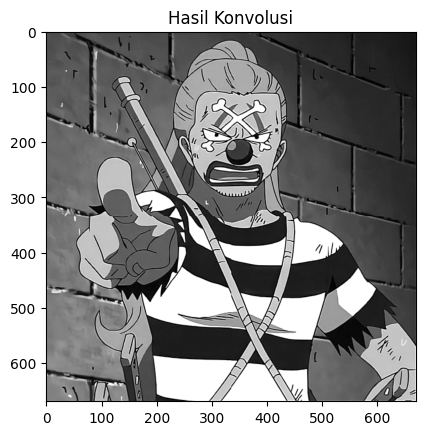

In [249]:
output = np.clip(output, 0, 255)
output = output.astype(np.uint8)

plt.imshow(output, cmap='gray')
plt.title("Hasil Konvolusi")
plt.show()

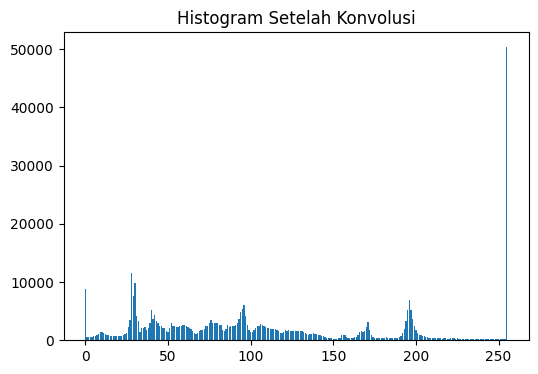

In [250]:
hist_konvolusi = np.zeros(256)

h, w = output.shape

for i in range(h):
    for j in range(w):
        hist_konvolusi[int(output[i, j])] += 1


plt.figure(figsize=(6,4))
plt.bar(range(256), hist_konvolusi)
plt.title("Histogram Setelah Konvolusi")
plt.show()